# Project 2: Weekly Study Schedule Optimization Using Combinatorial Optimization

#### Fanbo Feng, Chenyu Niu, Erhan Asad Javed

1. [Problem Statement](#problem-statement)
2. [Variables and Parameters](#variables-and-parameters)
3. [Assumptions](#assumptions)
4. [Constraints](#constraints)
5. [Objective Function](#objective-function)
6. [Solving the Model](#solving-the-model)

In [1]:
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

## Problem statement
Find the optimal time assigning strategy such that we can maximize the learning gain in a week with completing the assignment which is due in the week.

<div align="center">

<figure>
<img src="img/course_calendar.png" height="400" width="500">

<figcaption><em>Figure 1: Sample week schedule.</em></figcaption>

</figure>

</div>

## Variables and Parameters

| Symbol | Description | Type |
|:------:|-------------|:----:|
| $i \in I$ | Index for courses | index |
| $j \in J$ | Index for hourly time slots in a day ($0,\dots,23$) | index |
| $k \in K$ | Index for days of the week (Mon-Sun) | index |
| $t \in T$ | Index for possible starting hours of a 2-hour socializing block, where $T=\{17,18,19,20,21,22\}$ | index |
| $x_{ijk}$ | $x_{ijk}=1$ if self-study for course $i$ is scheduled at hour $j$ on day $k$, and $0$ otherwise | decision variable |
| $y_{ijk}$ | $y_{ijk}=1$ if class for course $i$ is attended at hour $j$ on day $k$, and $0$ otherwise | decision variable |
| $z_{ijk}$ | $z_{ijk}=1$ if assignment work for course $i$ is scheduled at hour $j$ on day $k$, and $0$ otherwise | decision variable |
| $s_{jk}$ | $s_{jk}=1$ if rest is scheduled at hour $j$ on day $k$, and $0$ otherwise | decision variable |
| $q_{jk}$ | $q_{jk}=1$ if socializing is scheduled at hour $j$ on day $k$, and $0$ otherwise | decision variable |
| $u_{tk}$ | $u_{tk}=1$ if a 2-hour consecutive socializing block starts at hour $t$ on day $k$, and $0$ otherwise | decision variable |
| $r_k$ | $r_k=1$ if day $k$ is counted as a socializing day, and $0$ otherwise | decision variable |
| $a_{ijk}$ | $a_{ijk}=1$ if course $i$ has a scheduled class at hour $j$ on day $k$, and $0$ otherwise | parameter |
| $\alpha_i$ | Learning gain from one hour of self-study for course $i$ | parameter |
| $\beta_i$ | Learning gain from one hour of attending class for course $i$ | parameter |
| $\gamma_i$ | Learning gain from one hour of assignment work for course $i$ | parameter |
| $\sigma_i$ | Assignment completion gained from one hour of assignment work for course $i$ | parameter |
| $L_i$ | Minimum number of class hours required per week for course $i$ | parameter |
| $A_i$ | Amount of assignment work required to complete the assignment for course $i$ before its due day | parameter |
| $D_i$ | Due day of course $i$, with Monday $=0$ and Sunday $=6$ | parameter |
| $P_i$ | Minimum prerequisite learning gain required before starting assignment work for course $i$ | parameter |
| $G_i$ | Maximum total learning gain obtainable for course $i$ | parameter |

In [2]:
# Sets
courses = ["MATH1", "HISTORY", "MATH2", "EOSC"]
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
hours = list(range(24))

I = range(len(courses))
J = range(len(hours))
K = range(len(days))

nI = len(courses)
nJ = len(hours)
nK = len(days)

course_to_idx = {c: i for i, c in enumerate(courses)}
day_to_idx = {d: k for k, d in enumerate(days)}

# sample parameters
# learning gain per hour (to be changed?)

#self-study-oriented student
alpha = np.array([8, 8, 8, 8])   # self-study gain
beta  = np.array([5, 5, 5, 5])   # class attendance gain
gamma = np.array([5, 5, 5, 5])   # assignment-work gain


# #class-oriented student
# alpha = np.array([5, 5, 5, 5])   # self-study gain
# beta  = np.array([8, 8, 8, 8])   # class attendance gain
# gamma = np.array([5, 5, 5, 5])   # assignment-work gain


# #assignment-oriented student
# alpha = np.array([5, 5, 5, 5])   # self-study gain
# beta  = np.array([5, 5, 5, 5])   # class attendance gain
# gamma = np.array([8, 8, 8, 8])   # assignment-work gain

# assignment completion per hour
sigma = np.array([1, 1, 1, 1])

# min class attendance hours required perweek
L = np.array([3, 2, 2, 2])

# Assignment work required (hours)
A = np.array([4, 3, 4, 3])

# Due days from the sample schedule
# Wed = EOSC, Fri = HISTORY, Sat = MATH2, Sun = MATH1
# Monday=0, Tues=1, ..., Sunday=6
D = np.array([
    6,  # MATH1 due Sunday
    4,  # HISTORY due Friday
    5,  # MATH2 due Saturday
    2   # EOSC due Wednesday
])

P = np.array([12, 8, 10, 6])   # example values

G = np.array([200, 200, 200, 200])   # example values

# class schedule a[i,j,k]
# a[i,j,k] = 1 if class is scheduled for course i at hour j on day k
a = np.zeros((nI, nJ, nK), dtype=int)

# social_day[k] = 1 if day k contains a valid 2-hour consecutive social block
social_day = cp.Variable(nK, boolean=True)

# social_start[t, k] = 1 when 2-hour socialising starts at hour t on day k
# allowed start times are 17,18,19,20,21,22 so that t and t+1 are both in 17:00-24:00
social_start = cp.Variable((6, nK), boolean=True)

def add_class(course, day, start_hour, end_hour):
    # Add class from start_hour to end_hour
    # e.g. 9 to 10 means one hour at hour 9
    i = course_to_idx[course]
    k = day_to_idx[day]
    for h in range(start_hour, end_hour):
        a[i, h, k] = 1

# MON
add_class("MATH1", "Mon", 9, 10)
add_class("HISTORY","Mon", 10, 11)
add_class("MATH2","Mon", 11, 12)

# WED
add_class("MATH1", "Wed", 9, 10)
add_class("HISTORY","Wed", 10, 11)
add_class("MATH2", "Wed", 11, 12)

# FRI
add_class("MATH1", "Fri", 9, 10)
add_class("MATH2", "Fri", 11, 12)

# THU
add_class("EOSC", "Thu", 11, 15)

# rest_fixed[j,k] = 1 if slot is forced to be rest/sleep
rest_fixed = np.zeros((nJ, nK), dtype=int)

# Sleep every day: 12am-8am
for k in K:
    for h in range(0,8):
        rest_fixed[h, k] = 1

# Rest every day: 5pm-7pm
for k in K:
    for h in range(17,19):
        rest_fixed[h, k] = 1

# Decision variables
x = cp.Variable((nI, nJ, nK), boolean=True) # self-study
y = cp.Variable((nI, nJ, nK), boolean=True) # class attendance
z = cp.Variable((nI, nJ, nK), boolean=True) # assignment work
s = cp.Variable((nJ, nK), boolean=True) # rest
q = cp.Variable((nJ, nK), boolean=True)   # socializing

## Assumptions

- all time is divided into 1-hour "blocks"
- student can only do one thing in each hour
- all hours in the week are assigned to exactly one activity
- learning gain per hour is constant within each course and activity type
- self-study, class attendance, and assignment work all contribute additively to total learning gain
- assignment progress increases linearly with each hour worked
- assignment work can be measured in equivalent hourly units
- due dates are treated at the day level, not exact submission times
- minimum class attendance requirement is known for each course
- prerequisite learning before assignment can be represented by accumulated learning gain from class + self-study
- maximum learning gain exists for each course, so extra hours eventually stop being useful
- rest/sleep blocks are fixed and cannot be changed
- socializing is only considered after 5pm
- a valid social day means at least 2 consecutive hours of socializing
- at least 3 social days per week are required
- no travel time between activities is considered
- no transition cost between switching activities is considered
- all courses are treated independently except for competing for the same time slots
- student energy, focus, and fatigue do not vary by day or hour
- quality of studying is assumed same regardless of when it happens
- assignment work for one course does not help learning in another course
- there are no unexpected events or schedule disruptions during the week
- parameter values like learning gain, prerequisite gain, and max gain are assumed known or estimated

## Constraints

In [3]:
constraints = []

### 1. Class Schedule Constraint

A student can only attend a class when the course is actually scheduled. Therefore, class attendance must not exceed the given class timetable.

$$
y_{ijk} \le a_{ijk} \quad , \forall i \in I, j \in J, k \in K
$$

In [4]:
for i in I:
    for j in J:
        for k in K:
            constraints.append(y[i,j,k] <= a[i,j,k])

### 2. Minimum Class Attendance

To ensure that the student attends at least a minimum number of class hours per week for each course, we have the following constraint:

$$
\sum_{j \in J} \sum_{k \in K} y_{ijk} \ge L_i \quad , \forall i \in I
$$

In [5]:
for i in I:
    constraints.append(cp.sum(y[i, :, :]) >= L[i])

### 3. Due Day Constraint

To ensure that the assignment for each course is completed exactly by its due date and that no assignment work is scheduled afterward, we have the following constraints:

$$
\sum_{j \in J}\sum_{k \in \{1,\dots,D_i\}} \sigma_i z_{ijk} = A_i
\quad , \forall i \in I
$$

$$
\sum_{j \in J}\sum_{k \in \{D_i+1,\dots,|K|\}} z_{ijk} = 0
\quad , \forall i \in I \text{ such that } D_i < |K|
$$

In [6]:
for i in I:
    due_day = D[i]

    # assignment must be completed exactly by the due date
    constraints.append(
        sigma[i] * cp.sum(z[i, :, 0:due_day+1]) == A[i]
    )

    # no assignment allowed after the due date
    if due_day + 1 < nK:
        constraints.append(
            cp.sum(z[i, :, due_day+1:nK]) == 0
        )

### 4. All Hours Must Be Scheduled

To ensure that every hourly time slot in the week is assigned to exactly one activity, each hour must be allocated to one of the following: self-study, class attendance, assignment work, rest, or socializing.

$$
\sum_{i \in I} x_{ijk}
+\sum_{i \in I} y_{ijk}
+\sum_{i \in I} z_{ijk}
+s_{jk}
+q_{jk}
= 1
\quad , \forall j \in J, k \in K
$$

In [7]:
for j in J:
    for k in K:
        constraints.append(
            cp.sum(x[:, j, k]) +
            cp.sum(y[:, j, k]) +
            cp.sum(z[:, j, k]) +
            s[j, k] +
            q[j, k] == 1
        )

### 5. Fixed Rest and Sleep Hours

Certain time slots are predetermined as rest or sleep periods according to the weekly schedule. During these hours, no studying, class attendance, assignment work, or socializing can occur.

For every hour $j \in J$ and day $k \in K$ such that $rest\_fixed_{jk} = 1$, we impose:

$$
s_{jk} = 1
$$

$$
q_{jk} = 0
$$

$$
\sum_{i \in I} x_{ijk} = 0
$$

$$
\sum_{i \in I} y_{ijk} = 0
$$

$$
\sum_{i \in I} z_{ijk} = 0
$$

In [8]:
for j in J:
    for k in K:
        if rest_fixed[j, k] == 1:
            constraints.append(s[j, k] == 1)
            constraints.append(q[j, k] == 0)
            constraints.append(cp.sum(x[:, j, k]) == 0)
            constraints.append(cp.sum(y[:, j, k]) == 0)
            constraints.append(cp.sum(z[:, j, k]) == 0)

### 6. Prerequisite learning gain for doing assignment

The student needs to obtain a required amount of learning gain of the certain course $i$ before doing the assignment:

$$
\sum_{k' = 1}^{k-1} \sum_{j' \in J} (\alpha_i x_{ij'k'} + \beta_i y_{ij'k'}) + \sum_{j' = 0}^{j-1} (\alpha_i x_{ij'k} + \beta_i y_{ij'k}) \ge P_i z_{ijk}, \quad \forall i \in I, j \in J, k\in K
$$

In [9]:
for i in I:
    for k in K:
        for j in J:

            prior_learning = 0

            # learning accumulated in previous days
            if k > 0:
                prior_learning += cp.sum(
                    alpha[i] * x[i, :, 0:k] +
                    beta[i]  * y[i, :, 0:k]
                )

            # learning accumulated earlier on the same day
            if j > 0:
                prior_learning += cp.sum(
                    alpha[i] * x[i, 0:j, k] +
                    beta[i]  * y[i, 0:j, k]
                )

            constraints.append(
                prior_learning >= P[i] * z[i, j, k]
            )

### 7. Maximum learning gain constraint

Each course have a maximum learning gain which can be obtained from study behaviors.

$$
\sum_{j \in J} \sum_{k \in K}
\left(
\alpha_i x_{ijk} + \beta_i y_{ijk} + \gamma_i z_{ijk}
\right) \le G_i , \quad \forall i \in I
$$

In [10]:
for i in I:
    constraints.append(
        cp.sum(
            alpha[i] * x[i, :, :] +
            beta[i]  * y[i, :, :] +
            gamma[i] * z[i, :, :]
        ) <= G[i]
    )

### 8. Socializing Constraint

To ensure that the student has time for socializing, we require that socializing takes place for at least two consecutive hours after 5pm on at least three days of the week.

Let $q_{jk}=1$ if socializing is scheduled at hour $j$ on day $k$, and $0$ otherwise.

Let $u_{tk}=1$ if a 2-hour consecutive socializing block starts at hour $t$ on day $k$, and $0$ otherwise, where

$$
t \in \{17,18,19,20,21,22\}
$$

Let $r_k=1$ if day $k$ is counted as a socializing day, and $0$ otherwise.

If a 2-hour socializing block starts at hour $t$ on day $k$, then both hour $t$ and hour $t+1$ must be assigned to socializing:

$$
q_{tk} \ge u_{tk}, \quad \forall k \in K,\; t \in \{17,18,19,20,21,22\}
$$

$$
q_{(t+1)k} \ge u_{tk}, \quad \forall k \in K,\; t \in \{17,18,19,20,21,22\}
$$

A day is counted as a socializing day only if it contains at least one valid 2-hour consecutive socializing block:

$$
\sum_{t \in \{17,18,19,20,21,22\}} u_{tk} \ge r_k, \quad \forall k \in K
$$

Finally, at least three days in the week must be counted as socializing days:

$$
\sum_{k \in K} r_k \ge 3
$$

In [11]:
for k in K:
    # if a social block starts at hour t, then both hours must be socializing
    for idx, t in enumerate(range(17, 23)):
        constraints.append(q[t, k] >= social_start[idx, k])
        constraints.append(q[t + 1, k] >= social_start[idx, k])

    # a day counts as a social day only if at least one 2-hour consecutive block exists
    constraints.append(cp.sum(social_start[:, k]) >= social_day[k])

# at least 3 days in the week must be social days
constraints.append(cp.sum(social_day) >= 3)

## Objective Function

The goal is to maximize the total learning gain obtained from self-study, attending classes, and completing assignments across all courses and time periods.

$$
\max \sum_{i \in I} \sum_{j \in J} \sum_{k \in K}
\left(
\alpha_i x_{ijk} + \beta_i y_{ijk} + \gamma_i z_{ijk}
\right)
$$

In [12]:
delta = 2

objective = cp.Maximize(
    cp.sum(cp.multiply(alpha[:, None, None], x)) +
    cp.sum(cp.multiply(beta[:, None, None], y)) +
    cp.sum(cp.multiply(gamma[:, None, None], z)) +
    delta * cp.sum(q)
)

## Solving the model

In [13]:
problem = cp.Problem(objective, constraints)
problem.solve()

print("Status:", problem.status)
print("Optimal learning gain:", problem.value)

/opt/anaconda3/envs/cpsc330/lib/python3.13/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


Status: optimal
Optimal learning gain: 679.0


In [14]:
def activity_label(j, k):
    if s.value[j, k] > 0.5:
        return "REST"

    if q.value[j, k] > 0.5:
        return "SOCIAL"

    for i, c in enumerate(courses):
        if x.value[i, j, k] > 0.5:
            return f"Study-{c}"
        if y.value[i, j, k] > 0.5:
            return f"Class-{c}"
        if z.value[i, j, k] > 0.5:
            return f"Assign-{c}"

    return "UNASSIGNED"

schedule = pd.DataFrame(index=[f"{h:02d}:00" for h in hours], columns=days)

for k, day in enumerate(days):
    for j, h in enumerate(hours):
        schedule.loc[f"{h:02d}:00", day] = activity_label(j, k)

print("\nWeekly Optimal Schedule:")
print(schedule)


Weekly Optimal Schedule:
                 Mon            Tue             Wed             Thu  \
00:00           REST           REST            REST            REST   
01:00           REST           REST            REST            REST   
02:00           REST           REST            REST            REST   
03:00           REST           REST            REST            REST   
04:00           REST           REST            REST            REST   
05:00           REST           REST            REST            REST   
06:00           REST           REST            REST            REST   
07:00           REST           REST            REST            REST   
08:00    Study-MATH2    Study-MATH2    Assign-MATH2    Assign-MATH1   
09:00    Class-MATH1     Study-EOSC     Class-MATH1  Assign-HISTORY   
10:00  Class-HISTORY     Study-EOSC   Class-HISTORY      Study-EOSC   
11:00    Class-MATH2    Study-MATH2     Class-MATH2     Study-MATH1   
12:00   Assign-MATH2  Study-HISTORY     Study-MATH1

In [15]:
# summary by course
summary_rows = []
for i, c in enumerate(courses):
    study_hours = int(np.round(np.sum(x.value[i, :, :])))
    class_hours = int(np.round(np.sum(y.value[i, :, :])))
    assign_hours = int(np.round(np.sum(z.value[i, :, :])))
    summary_rows.append([c, study_hours, class_hours, assign_hours])

summary = pd.DataFrame(summary_rows, columns=["Course", "SelfStudyHours", "ClassHours", "AssignmentHours"])
print("\nSummary:")
print(summary)


Summary:
    Course  SelfStudyHours  ClassHours  AssignmentHours
0    MATH1              20           3                4
1  HISTORY              14           2                3
2    MATH2              21           2                4
3     EOSC              14           2                3


/var/folders/dy/c6xv5fkn551gkg8zdwllp21h0000gn/T/ipykernel_57307/404888817.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  schedule_num = schedule.replace(label_to_num).astype(int)


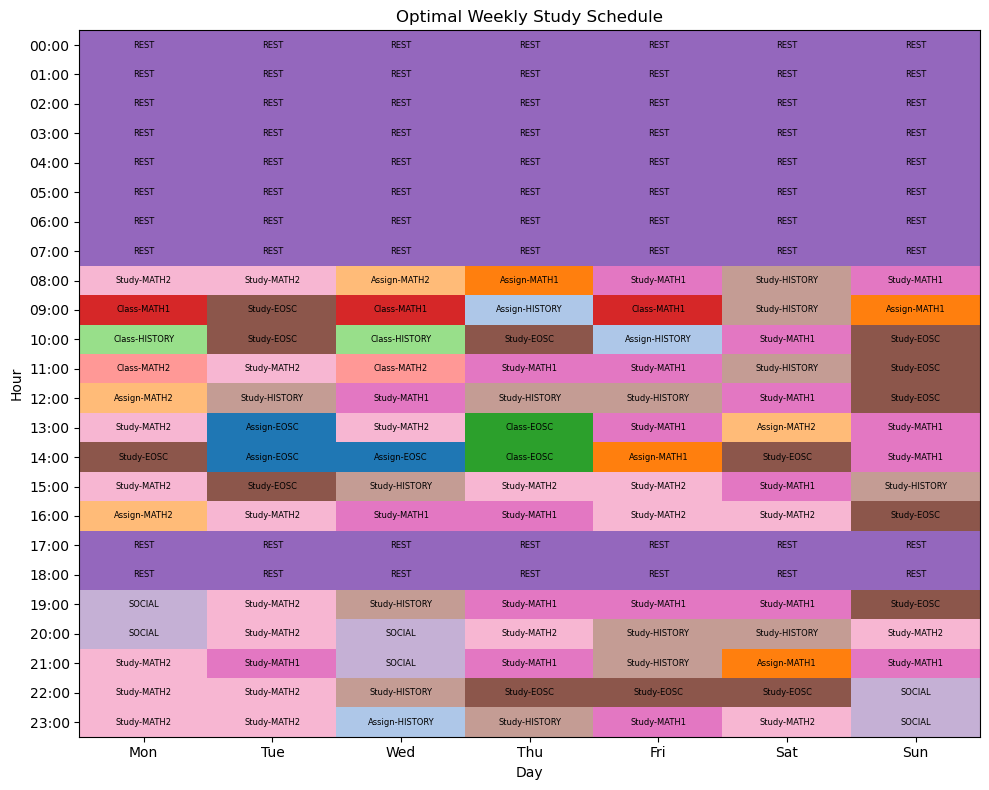

In [16]:
# Convert schedule labels to category codes
unique_labels = sorted(pd.unique(schedule.values.ravel()))
label_to_num = {label: i for i,label in enumerate(unique_labels)}
num_to_label = {i: label for label, i in label_to_num.items()}

schedule_num = schedule.replace(label_to_num).astype(int)

fig, ax = plt.subplots(figsize=(10, 8))
cmap = ListedColormap(plt.cm.tab20.colors[:len(unique_labels)])

im = ax.imshow(schedule_num.values, aspect='auto', cmap=cmap)

# Axis labels
ax.set_xticks(np.arange(len(schedule.columns)))
ax.set_xticklabels(schedule.columns)
ax.set_yticks(np.arange(len(schedule.index)))
ax.set_yticklabels(schedule.index)

ax.set_xlabel("Day")
ax.set_ylabel("Hour")
ax.set_title("Optimal Weekly Study Schedule")

# write activity text inside cells
for i in range(schedule_num.shape[0]):
    for j in range(schedule_num.shape[1]):
        ax.text(j, i, schedule.iloc[i, j], ha="center", va="center", fontsize=6)

plt.tight_layout()
plt.show()

## needed help with AI to generate this plot 

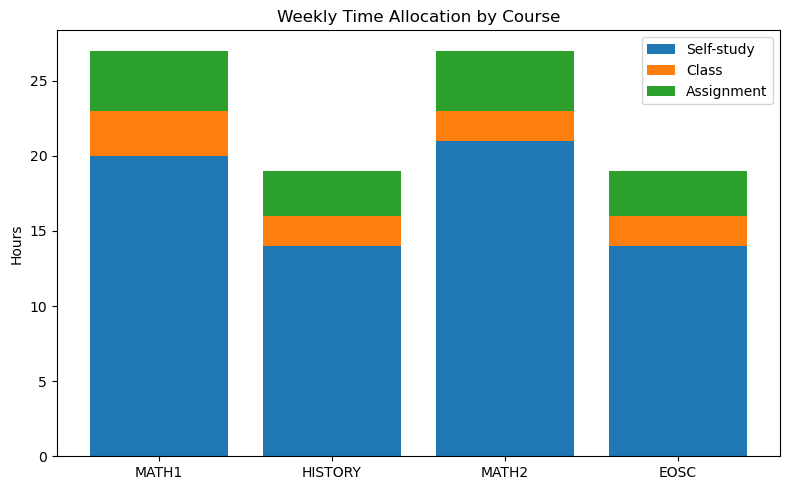

In [17]:
summary = pd.DataFrame(summary_rows, columns=["Course", "SelfStudyHours", "ClassHours", "AssignmentHours"])

x = np.arange(len(summary))

plt.figure(figsize=(8, 5))
plt.bar(x,summary["SelfStudyHours"], label="Self-study")
plt.bar(x,summary["ClassHours"], bottom=summary["SelfStudyHours"], label="Class")
plt.bar(
    x,
    summary["AssignmentHours"],
    bottom=summary["SelfStudyHours"] + summary["ClassHours"],
    label="Assignment"
)

plt.xticks(x, summary["Course"])
plt.ylabel("Hours")
plt.title("Weekly Time Allocation by Course")
plt.legend()
plt.tight_layout()
plt.show()

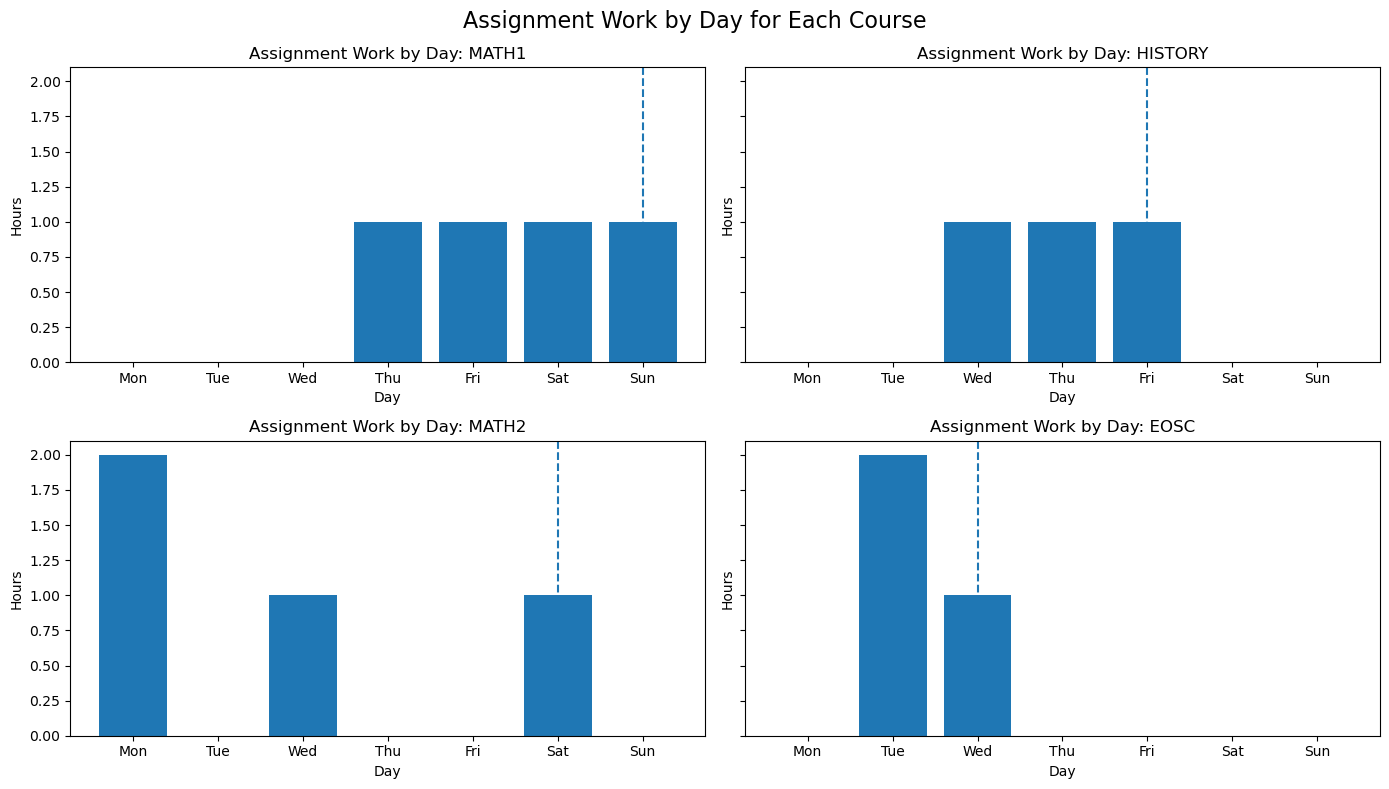

In [18]:
assignment_progress = []

for i, course in enumerate(courses):
    for k, day in enumerate(days):
        hours_done = int(np.round(np.sum(z.value[i, :, k])))
        assignment_progress.append([course, day, k, hours_done, D[i]])

assignment_df = pd.DataFrame(
    assignment_progress,
    columns=["Course", "Day", "DayIndex", "AssignmentHours", "DueDay"]
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for idx, course in enumerate(courses):
    temp = assignment_df[assignment_df["Course"] == course]
    ax = axes[idx]
    
    ax.bar(temp["Day"], temp["AssignmentHours"])
    ax.axvline(
        x=temp["DueDay"].iloc[0],
        linestyle="--"
    )
    ax.set_title(f"Assignment Work by Day: {course}")
    ax.set_ylabel("Hours")
    ax.set_xlabel("Day")
    ax.set_xticks(range(len(days)))
    ax.set_xticklabels(days)

plt.tight_layout()
plt.suptitle("Assignment Work by Day for Each Course", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()